## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def describe_all_values(df: pd.DataFrame):
    return pd.Series(df.values.flatten()).describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99],
    )

In [3]:
def plot_kmer_counts_vs_presence_in_accessions(df: pd.DataFrame):
    fig, axs = plt.subplots(ncols=4, sharey=True, figsize=(16, 4))

    sns.histplot((df == 0).sum(axis=1), binwidth=4, ax=axs[0]).set_title("Zero Counts")
    sns.histplot((df < 2).sum(axis=1), binwidth=4, ax=axs[1]).set_title("Zero or Low (< 2) Counts")
    sns.histplot((df < 4).sum(axis=1), binwidth=4, ax=axs[2]).set_title("Zero or Low (< 4) Counts")
    sns.histplot((df < 8).sum(axis=1), binwidth=4, ax=axs[3]).set_title("Zero or Low (< 8) Counts")

## 1. Load and Describe Data

In [4]:
df_meta = pd.read_csv('../SraRunTable.csv', usecols=['Run', 'Bases', 'Bytes'])
df_meta['Coverage'] = df_meta['Bases'] / 133_917_231  # Number of Bases in ColPEK Assembly
df_meta

,Run,Bases,Bytes,Coverage
0,SRR6862404,3961439247,1293517909,29.581251
1,SRR6862405,1421272374,558725270,10.613066
2,SRR6862406,2795990745,895548902,20.878499
3,SRR6862407,4622783460,1432583424,34.519706
4,SRR6862408,3599274656,1133648998,26.876860
...,...,...,...,...
209,SRR6750193,2922793146,1449894043,21.825370
210,SRR6750194,6752190804,2976980786,50.420627
211,SRR6750199,2640499552,1340584186,19.717400
212,SRR6750200,1904903656,963701635,14.224485


In [5]:
# get name of accessions that has at least 20x coverage
accessions_20x = df_meta.loc[df_meta['Coverage'] >= 20, 'Run'].values
print(f"Number of accessions with at least 20x coverage: {len(accessions_20x)}")

Number of accessions with at least 20x coverage: 179


In [6]:
df0 = pd.read_feather("../data/joined-counts.f32.zstd-8.feather", columns=["kmer", *accessions_20x])
df0.shape

(37175983, 179)

In [7]:
df0.dropna(how='all', inplace=True)
df0.shape

(18822594, 179)

In [8]:
df0.fillna(0, inplace=True)

In [9]:
df0.to_feather("../data/joined-counts.20x-cov.na-filled.zstd-8.feather", compression='zstd', compression_level=8)

In [10]:
describe_all_values(df0.sample(1_000_000))

count    1.790000e+08
mean     2.337216e+00
std      3.238950e+01
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
10%      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      1.488269e+00
95%      3.067391e+00
99%      1.853770e+01
max      1.702256e+04
dtype: float64

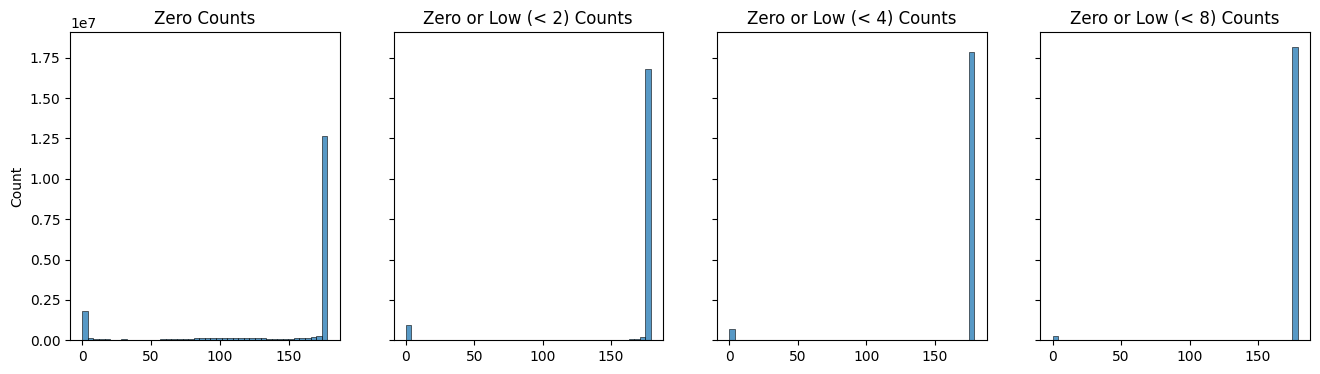

In [11]:
plot_kmer_counts_vs_presence_in_accessions(df0)

## 2. Filtering & Clustering

In [5]:
df0 = pd.read_feather("../data/joined-counts.20x-cov.na-filled.zstd-8.feather")

### 2.1 Initial Filtering

In [12]:
# Filter out Kmers that are only present or missing in few accessions
df1 = df0.loc[(df0 > 0).sum(axis=1) >= 9]
df1.shape

(5915174, 179)

In [13]:
df1.to_feather("../data/joined-counts.df1.zstd8.feather", compression="zstd", compression_level=8)

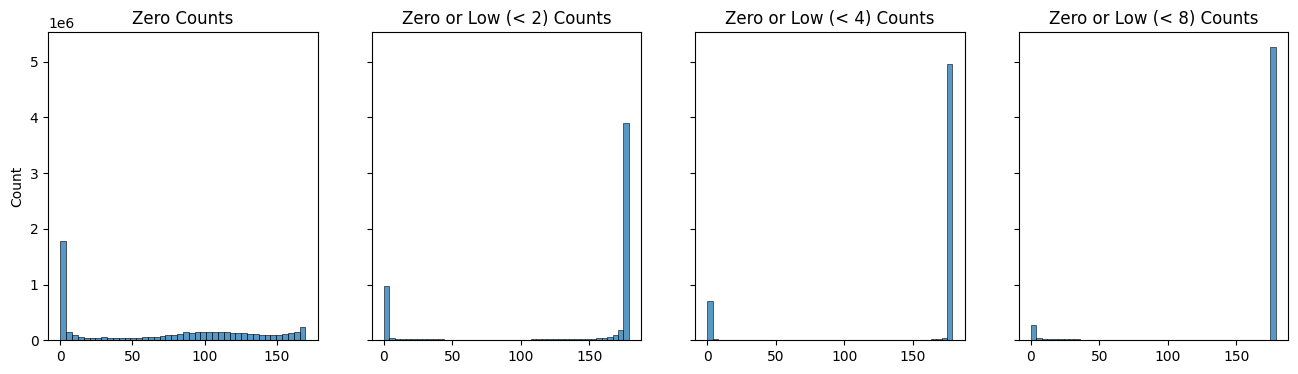

In [14]:
plot_kmer_counts_vs_presence_in_accessions(df1)

In [15]:
describe_all_values(df1)

count    1.058816e+09
mean     7.531542e+00
std      7.147518e+01
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
10%      0.000000e+00
25%      0.000000e+00
50%      1.085258e+00
75%      1.837446e+00
90%      7.247383e+00
95%      1.079451e+01
99%      1.949025e+02
max      5.910140e+04
dtype: float64

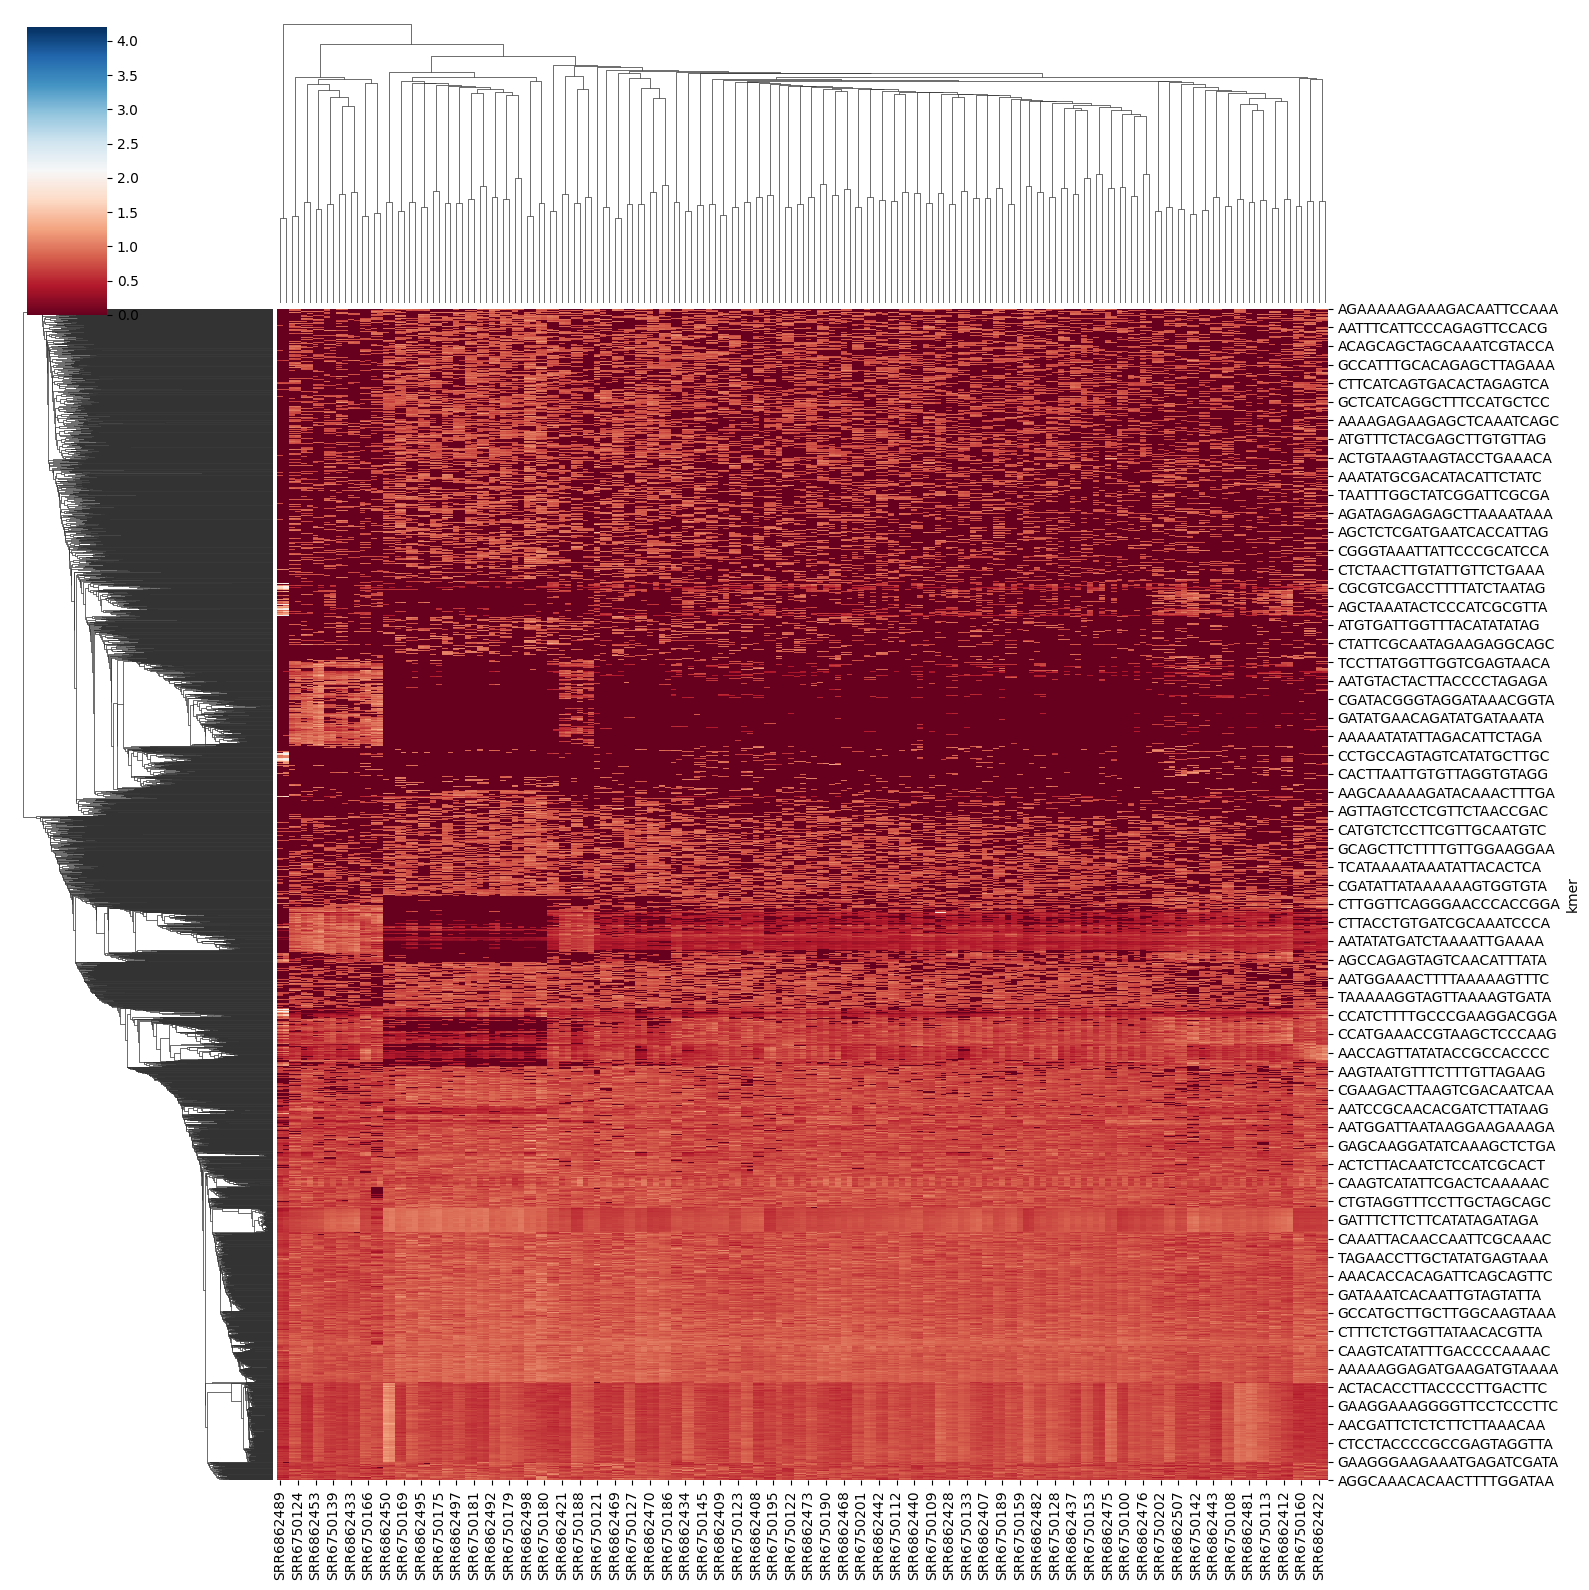

In [37]:
sampled = df1.sample(n=4096)
# Normalize by 99th percentile
sampled = sampled.div(sampled.quantile(0.99, axis=1), axis=0)
sns.clustermap(
    sampled,
    cmap="RdBu",
    figsize=(16, 16),
)

### 2.2 Further Filtering

In [23]:
# Further filter Kmers that are repeated in many accessions
df2 = df1.loc[(df1 >= 2).sum(axis=1) >= 9]
df2.shape

(1810741, 179)

In [25]:
df2.to_feather("../data/joined-counts.df2.zstd8.feather", compression="zstd", compression_level=8)

In [26]:
describe_all_values(df2)

count    3.241226e+08
mean     2.337367e+01
std      1.277700e+02
min      0.000000e+00
1%       0.000000e+00
5%       1.215402e+00
10%      1.502277e+00
25%      1.979285e+00
50%      3.241100e+00
75%      8.890282e+00
90%      2.045857e+01
95%      1.667667e+02
99%      3.422175e+02
max      5.910140e+04
dtype: float64

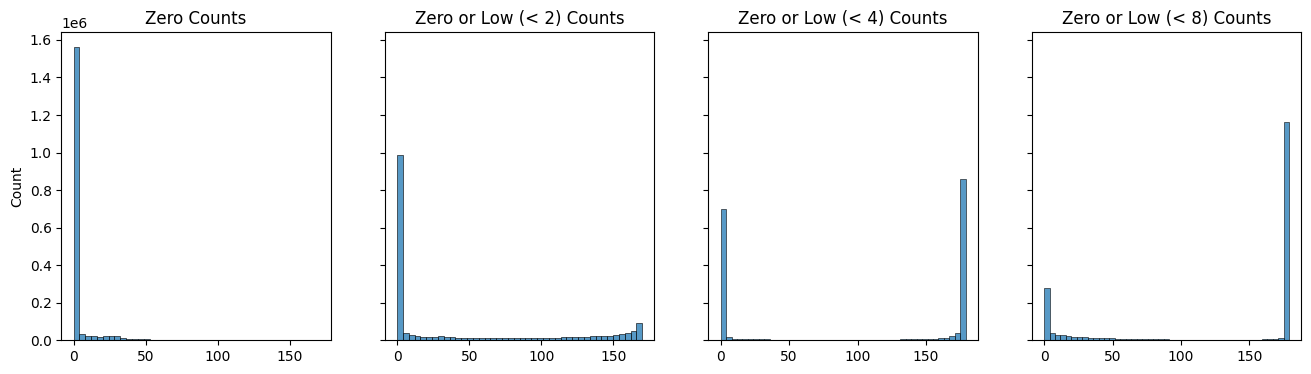

In [27]:
plot_kmer_counts_vs_presence_in_accessions(df2)

In [28]:
from scipy.stats import zscore

sampled = df2.sample(n=4096)
# sampled.apply(lambda x: np.log1p(x))
# Normalize by 99th percentile
sampled = sampled.div(sampled.quantile(0.99, axis=1), axis=0)
# sampled = pd.DataFrame(zscore(sampled, axis=1), index=sampled.index, columns=sampled.columns)
# sampled.apply(lambda x: np.log1p(x))
# sampled.shape
sampled

,SRR6862404,SRR6862406,SRR6862407,SRR6862408,SRR6862409,SRR6862410,SRR6862411,SRR6862412,SRR6862413,SRR6862414,...,SRR6750179,SRR6750180,SRR6750181,SRR6750188,SRR6750190,SRR6750191,SRR6750192,SRR6750193,SRR6750194,SRR6750204
kmer,,,,,,,,,,,,,,,,,,,,,
CAACCAATTGTAGTTGATGAGCG,0.656686,0.679916,0.725068,0.778359,0.681055,0.721419,0.808397,0.718747,0.692721,0.665778,...,0.643083,0.913512,0.729587,0.786667,0.764297,0.711779,0.895725,0.770232,0.777950,0.614918
AAGGCGGCATTGCACGAGGTGGT,0.673391,0.731048,0.756915,0.654521,0.819743,0.926651,0.694174,0.920469,0.748819,0.897408,...,0.867954,0.595831,0.859383,0.805312,0.799933,0.864042,0.744352,0.723038,0.841451,0.749836
TAGTATTACACAGAAGAAATCAA,0.848573,0.716724,0.766834,0.794788,0.756819,0.853271,0.841964,0.916489,0.900220,0.688913,...,0.912035,0.854688,0.976484,0.616681,0.720571,0.737912,0.650169,0.665110,0.989669,0.731847
CTTATACTGAATTATACACATGA,0.536643,0.872145,0.622177,0.712244,0.830939,0.858026,0.889119,0.566062,0.633503,0.742957,...,0.672524,0.000000,0.698811,0.983204,0.998665,1.004732,0.870729,0.705953,0.759327,0.852083
ACTCCTTTTTGGGCCAGAGACAG,0.663183,0.668426,0.642232,0.643866,0.640395,0.693017,0.683382,0.649465,0.656432,0.814686,...,0.741038,0.587299,0.675390,0.819584,0.643358,0.645323,0.484408,0.599234,0.667450,0.693441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AACATCTAAGGGCATCACAGACC,0.607099,0.532493,0.602905,0.547651,0.642995,0.629444,0.533954,0.577004,0.588125,0.689813,...,0.915487,1.134486,0.645359,0.853946,0.828219,0.830745,0.754620,0.782980,0.908770,0.653033
GTTGGTTCTGAACGCTGACCCAA,0.716017,0.811579,0.613583,0.557707,0.608215,0.690178,0.705148,0.549654,0.766362,0.705190,...,0.812803,0.648589,0.999214,0.850284,0.818200,0.715827,0.833412,0.880881,0.891862,0.664645
GACACGGCCGATGAAGTCTCGGA,0.607365,0.509190,0.566670,0.545858,0.613752,0.625845,0.427904,0.582808,0.596218,0.659758,...,0.789933,1.015696,0.665573,0.749484,0.810704,0.867434,0.641991,0.730649,0.862372,0.677155


/home/hazy/repos/genome/cen-kmers/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/hazy/repos/genome/cen-kmers/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


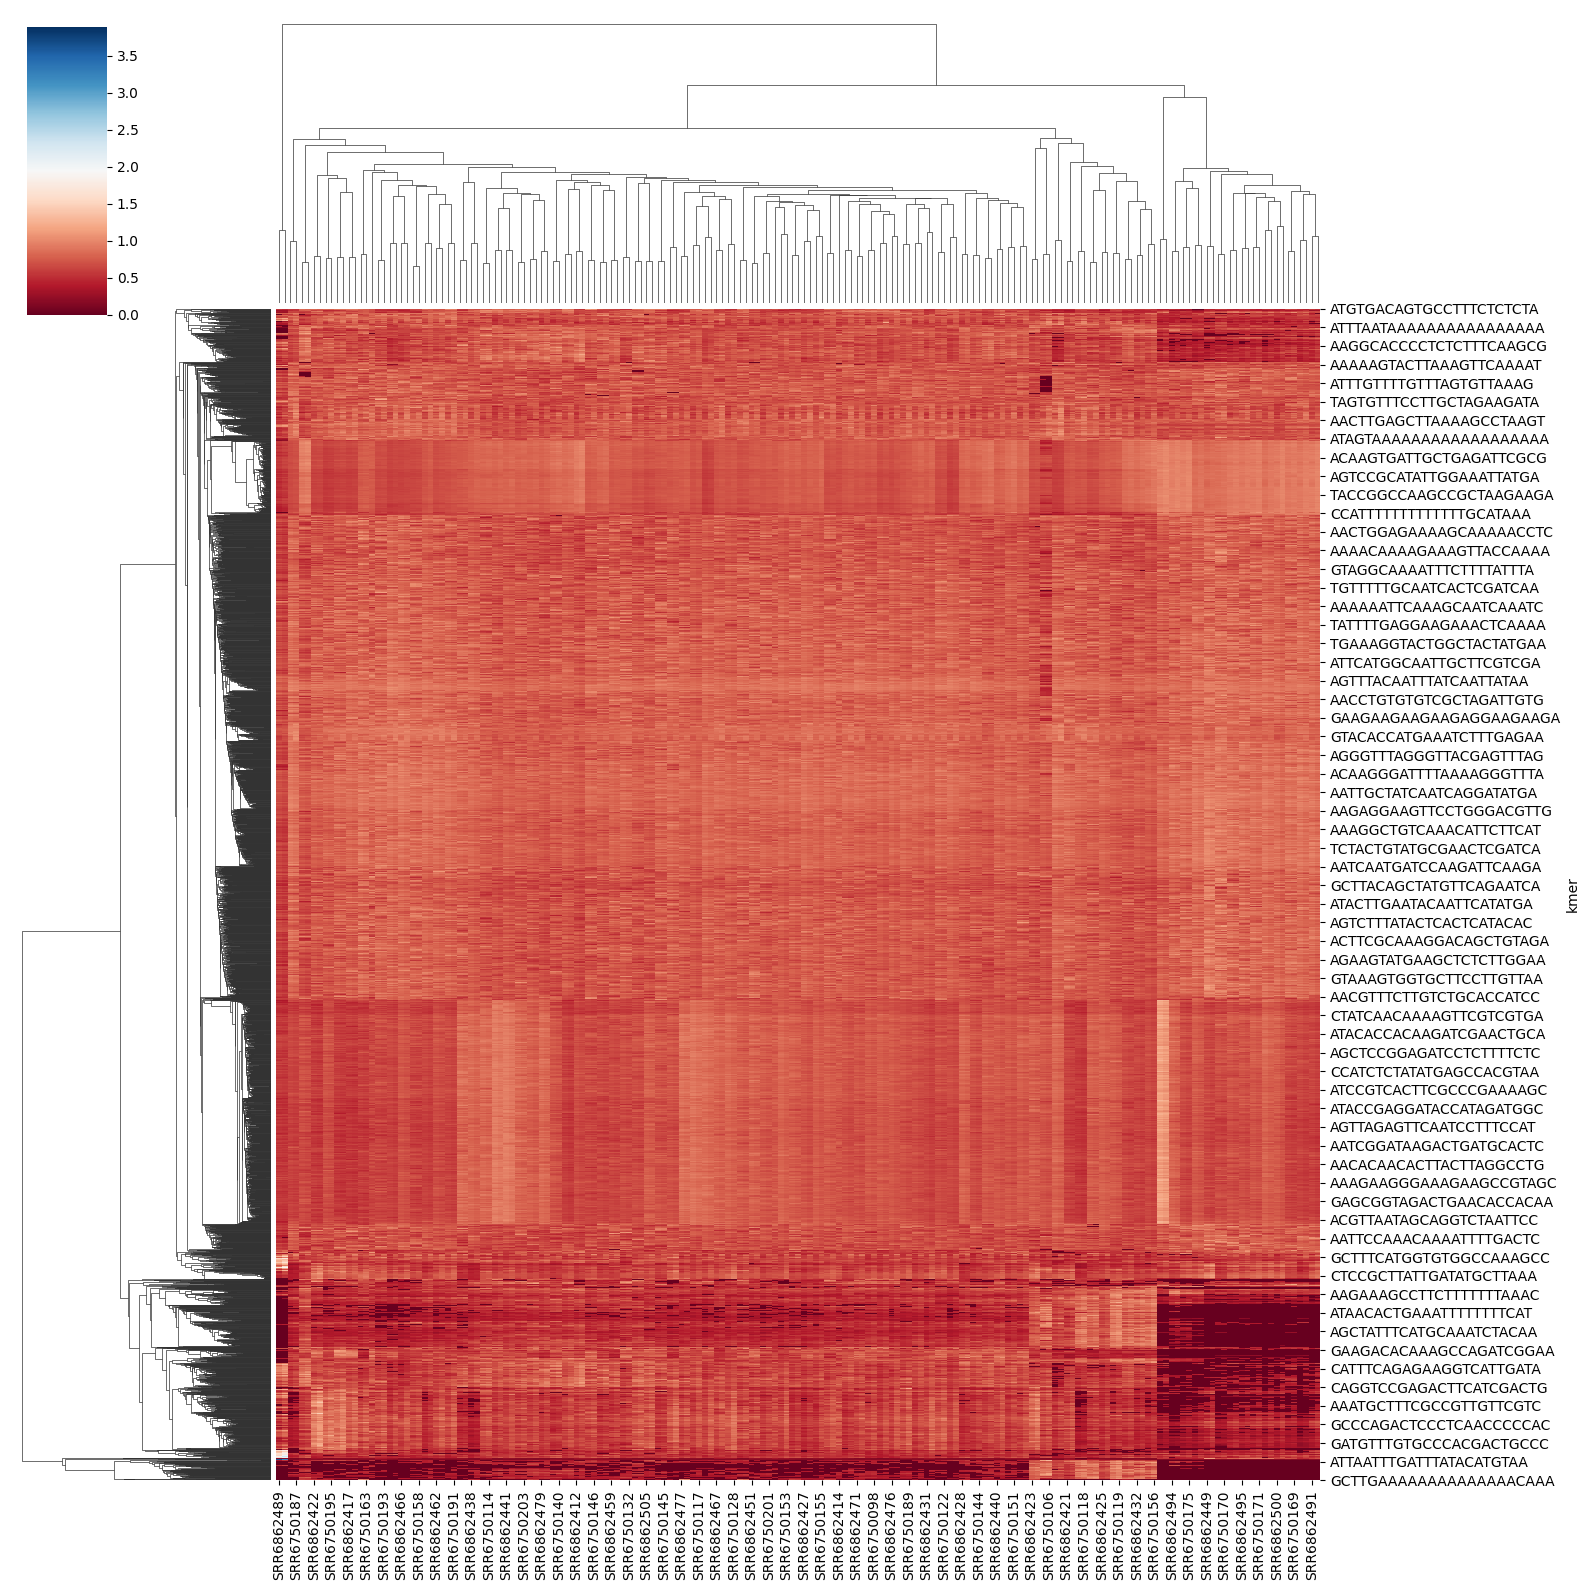

In [29]:
sns.clustermap(
    sampled,
    cmap="RdBu",
    figsize=(16, 16),
)

### 2.3 Further Filtering

In [30]:
df3 = df2.loc[(df2 == 0).sum(axis=1) >= 9]
df3.shape

(216196, 179)

In [41]:
df3.to_feather("../data/joined-counts.df3.zstd8.feather", compression="zstd", compression_level=8)

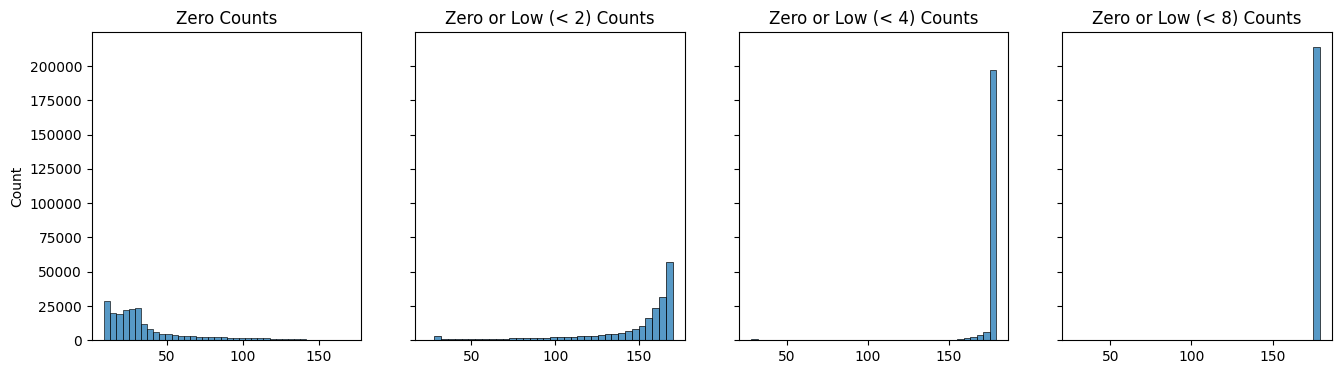

In [31]:
plot_kmer_counts_vs_presence_in_accessions(df3)

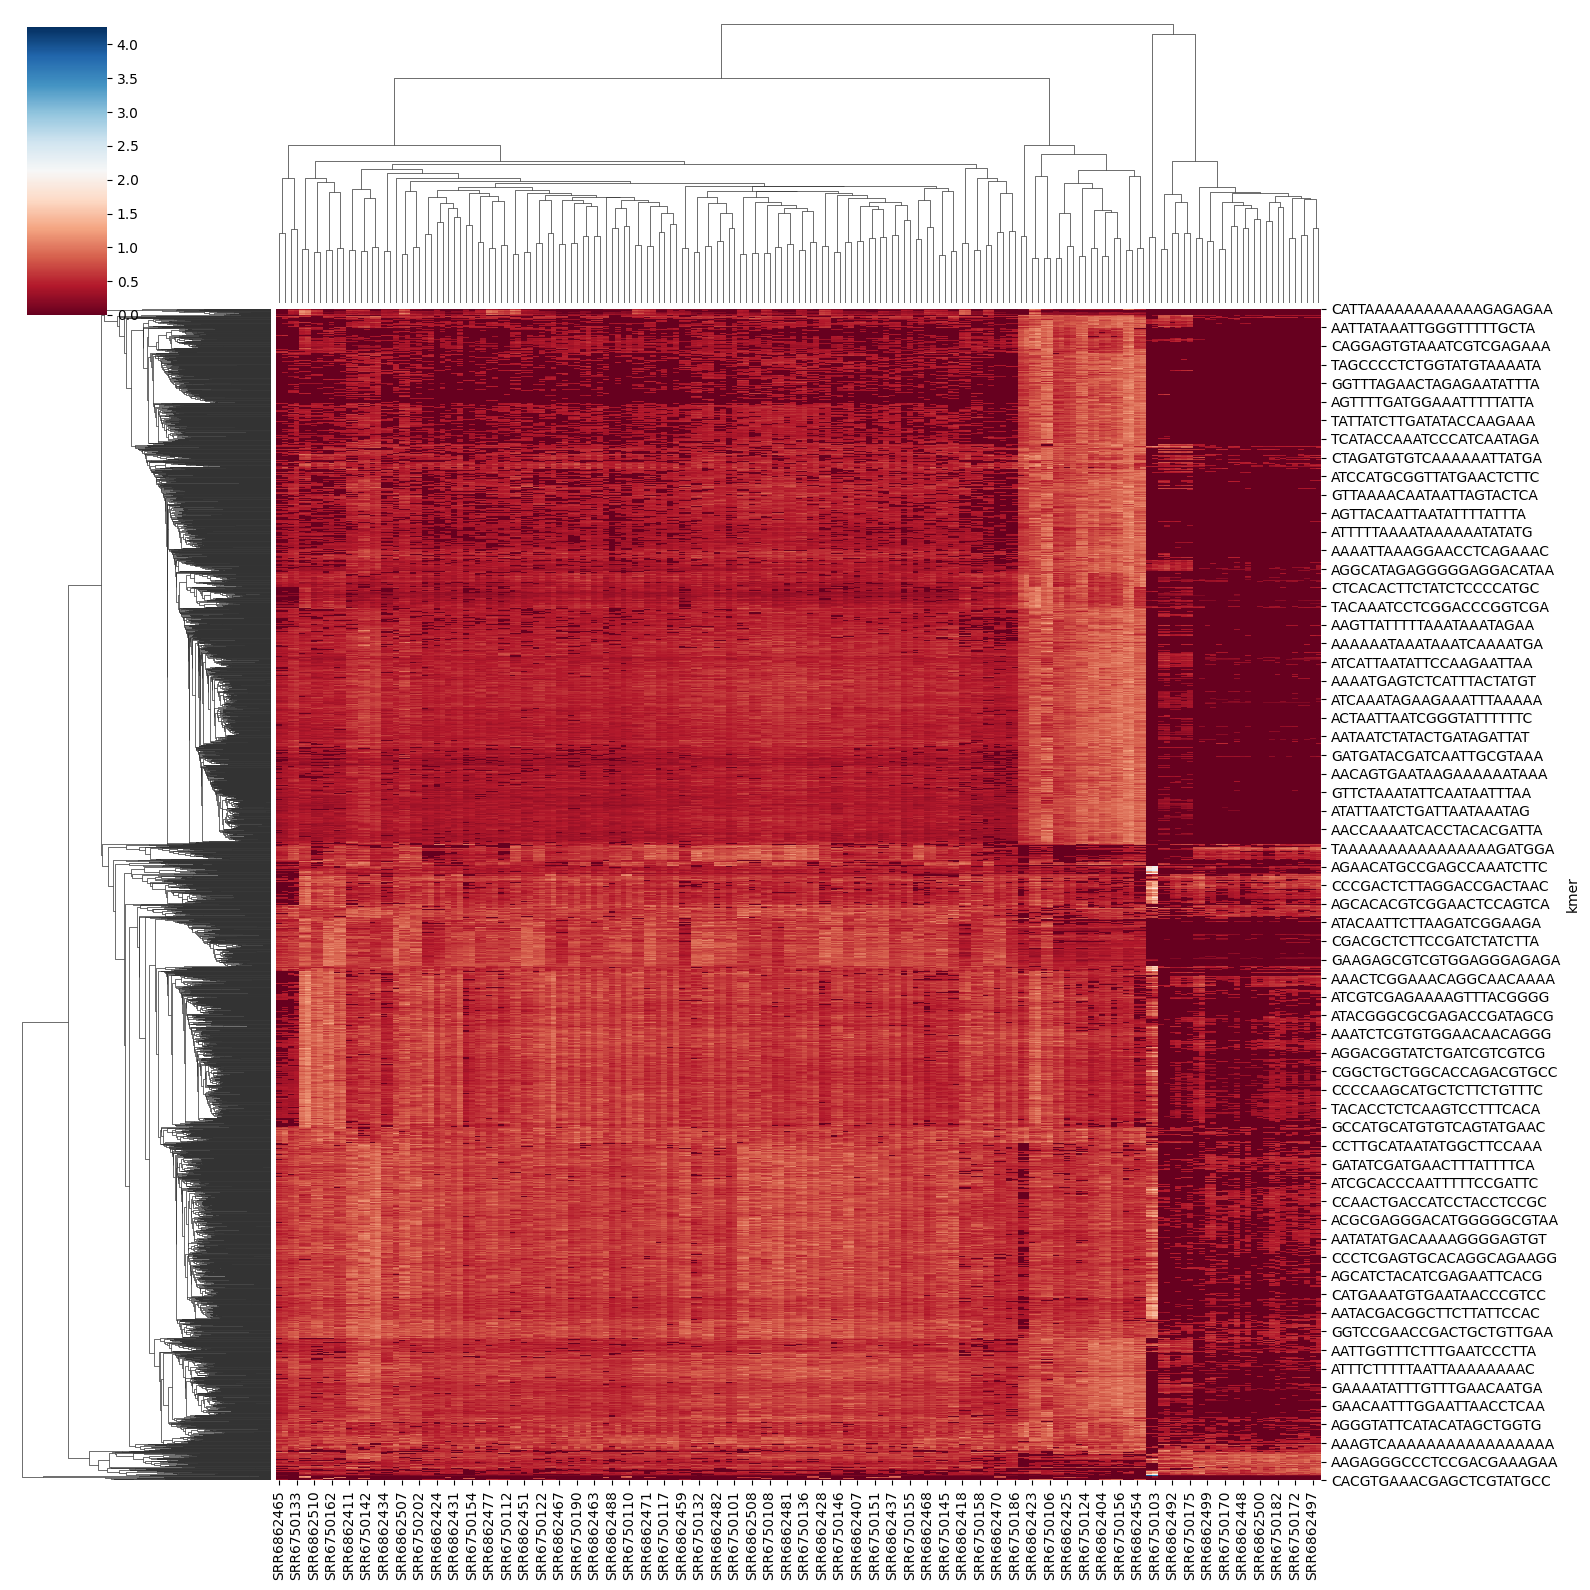

In [36]:
sampled = df3.sample(n=4096)
# Normalize by 99th percentile
sampled = sampled.div(sampled.quantile(0.99, axis=1), axis=0)
sns.clustermap(
    sampled,
    cmap="RdBu",
    figsize=(16, 16),
)

### 2.4 Further Filtering

In [39]:
df4 = df3.loc[(df3 >= 3).sum(axis=1) >= 9]
df4.shape

(37183, 179)

In [43]:
df4.to_feather("../data/joined-counts.df4.zstd8.feather", compression="zstd", compression_level=8)

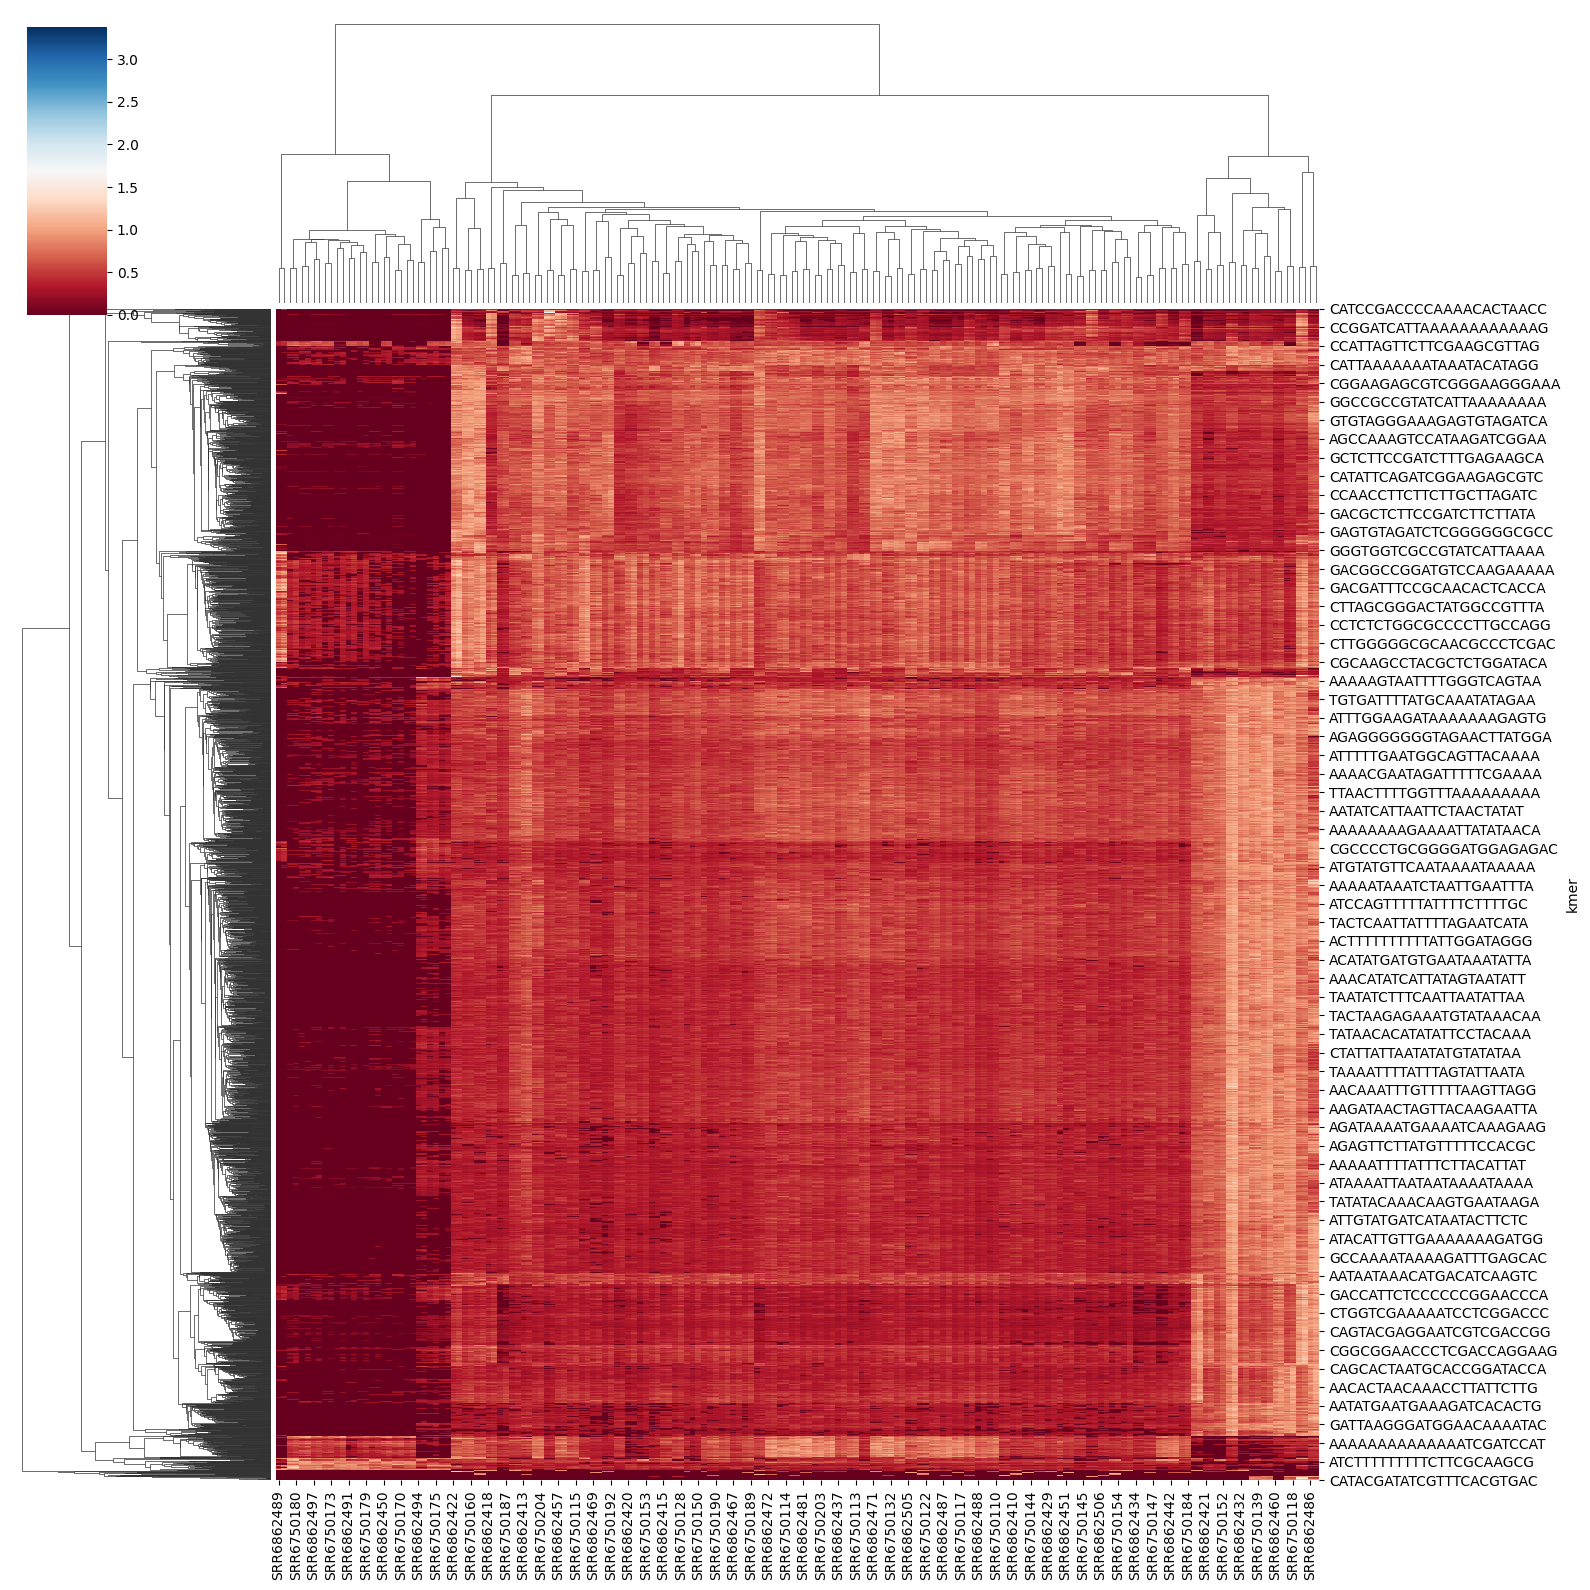

In [42]:
sampled = df4.sample(n=4096)
# Normalize by 99th percentile
sampled = sampled.div(sampled.quantile(0.99, axis=1), axis=0)

sns.clustermap(
    sampled,
    cmap="RdBu",
    figsize=(16, 16),
)